In [1]:
from src.data_loader import load_training_data
from src.preprocessing import preprocess
from src.feature_extraction import welch_method, extract_spectral_features, extract_features
import config
import matplotlib.pyplot as plt
import numpy as np


c:\Users\filip\OneDrive\Dokument\GitHub\cm2013_ht25_project\.venv\Lib\site-packages\nolds\datasets.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Loading training data from ../data/training/R1.edf and ../data/training/R1.xml...
Identified channels:
  EEG: ['EEG(sec)', 'EEG']
  EOG: ['EOG(L)', 'EOG(R)']
  EMG: ['EMG']
  EEG: 2 channels, 3750 samples/epoch, 125.0 Hz
  EOG: 2 channels, 3750 samples/epoch, 125.0 Hz
  EMG: 1 channels, 3750 samples/epoch, 125.0 Hz

Loaded 1083 epochs (9.03 hours)
Sleep stage distribution:
  Wake: 332 epochs (30.7%)
  N1: 47 epochs (4.3%)
  N2: 457 epochs (42.2%)
  N3: 145 epochs (13.4%)
  REM: 102 epochs (9.4%)
Preprocessing data for iteration 1...
Processing multi-channel data (EEG + EOG + EMG)
EEG sampling frequency: 125.0 Hz
Processing EEG channel 1
Processing EEG channel 2
Iteration 1: Processing EEG channels only


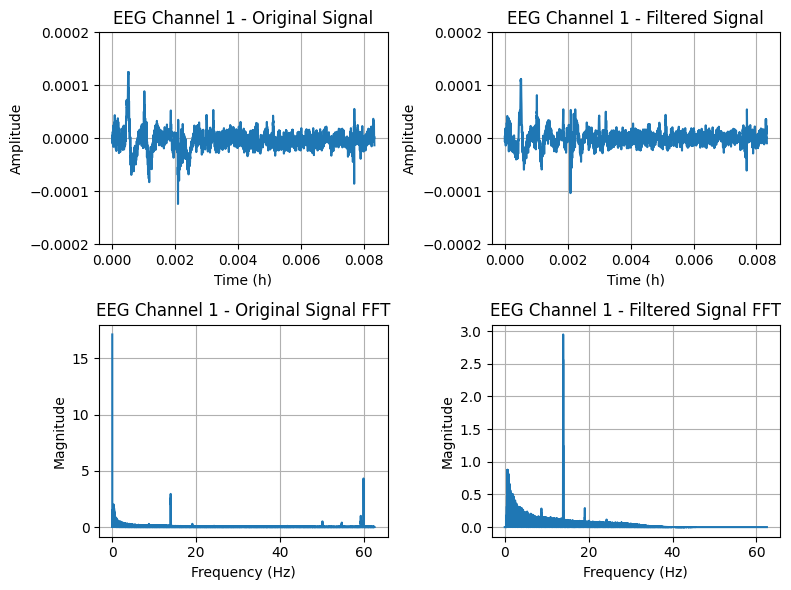

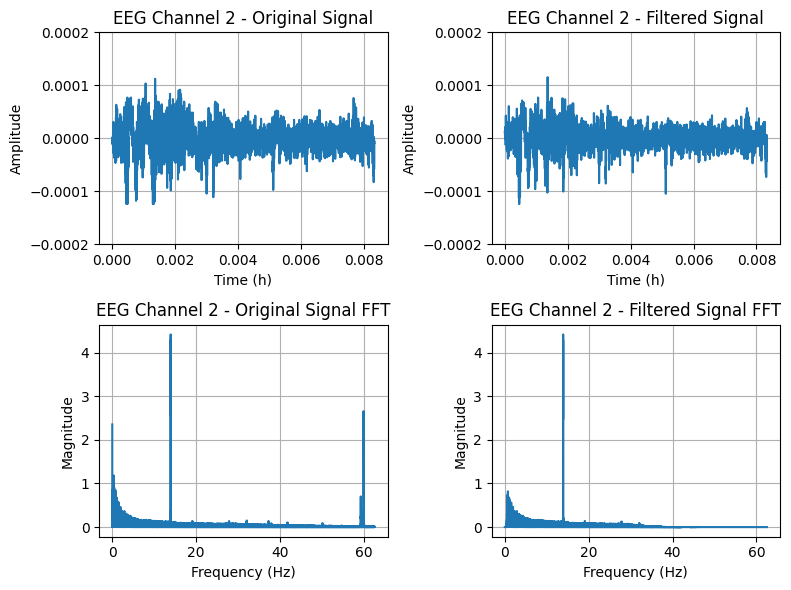

In [2]:
data,_,channel_info = load_training_data('../data/training/R1.edf', '../data/training/R1.xml')
data = preprocess(data,channel_info, config)

7.964689363372177e-11
1.8971778518025044e-11
2.5557567246005903e-11
9.288816872689588e-11
{'delta_power': np.float64(7.964689363372177e-11), 'delta_power_rel': np.float64(0.3586259427414373), 'theta_power': np.float64(1.8971778518025044e-11), 'theta_power_rel': np.float64(0.08542419730513914), 'alpha_power': np.float64(2.5557567246005903e-11), 'alpha_power_rel': np.float64(0.11507801785625336), 'beta_power': np.float64(9.288816872689588e-11), 'beta_power_rel': np.float64(0.4182474112851613)}
{'delta_power': np.float64(7.964689363372177e-11), 'delta_power_rel': np.float64(0.3586259427414373), 'theta_power': np.float64(1.8971778518025044e-11), 'theta_power_rel': np.float64(0.08542419730513914), 'alpha_power': np.float64(2.5557567246005903e-11), 'alpha_power_rel': np.float64(0.11507801785625336), 'beta_power': np.float64(9.288816872689588e-11), 'beta_power_rel': np.float64(0.4182474112851613), 'spectral_entropy': np.float64(0.9210348107000459), 'peak_freq': np.float64(0.75), 'sef90': np.f

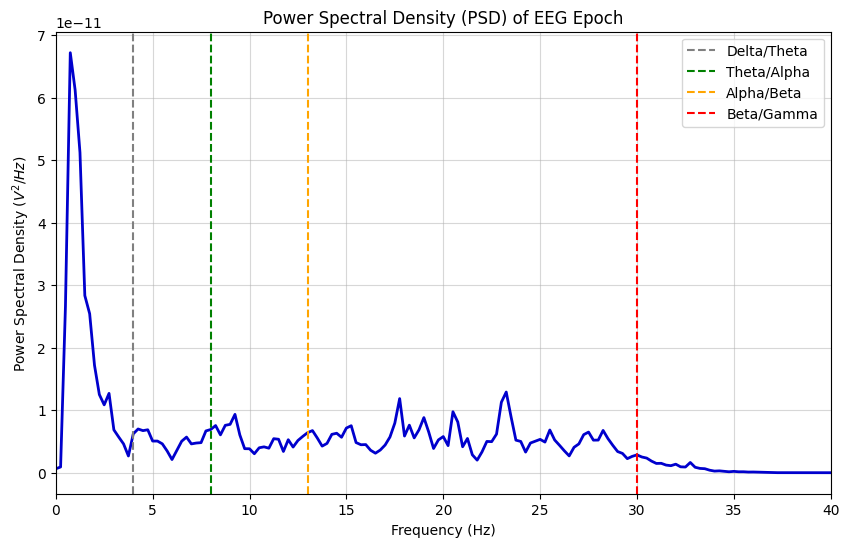

In [ ]:
epoch = data['eeg'][10,0,:]  # First epoch, first channel
fs = 125
window = 'hann'
nperseg = 4*fs
noverlap = 0.5 * nperseg
scaling = 'density'
nfft = nperseg
freqs, psd = welch_method(epoch, fs, window, nperseg, noverlap, nfft, scaling, config)
features = extract_spectral_features(freqs, psd, config)

# --- 2. Plotting the PSD ---
plt.figure(figsize=(10, 6))

# Plot the PSD (x-axis=frequencies, y-axis=power)
plt.plot(freqs, psd, color='mediumblue', linewidth=2)

# --- 3. Adding Labels and Title ---
plt.title('Power Spectral Density (PSD) of EEG Epoch')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density ($ V^2 / Hz$)')

# --- 4. Customizing the View ---
# Set the x-axis limits (optional, but good for focusing on EEG bands)
plt.xlim([0, 40]) 
# Add vertical lines to mark common EEG band boundaries
plt.axvline(x=4, color='gray', linestyle='--', label='Delta/Theta')
plt.axvline(x=8, color='green', linestyle='--', label='Theta/Alpha')
plt.axvline(x=13, color='orange', linestyle='--', label='Alpha/Beta')
plt.axvline(x=30, color='red', linestyle='--', label='Beta/Gamma')

plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

print(features)
